# 第056讲 可信分类阶段项目
本Notebook在CPU从数据真实重跑76次拟合。结果不是从已保存JSON粘贴。执行前先读data/protocol.json：阈值、成本、搜索空间不能根据最终测试修改。独立讲义、实验和答案见同目录PDF。

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image
import experiment as e
from test_experiment import audit
from plots import make_figures
ROOT = Path.cwd()
protocol = json.loads((ROOT / "data/protocol.json").read_text())
protocol

{'unit': '056',
 'seed': 5600,
 'n_development': 1200,
 'n_test': 600,
 'outer_folds': 3,
 'inner_folds': 3,
 'degrees': [1, 2],
 'Cs': [0.1, 1.0, 10.0],
 'thresholds': [0.1, 0.2, 0.3, 0.4, 0.5],
 'false_negative_cost': 4,
 'false_positive_cost': 1,
 'tie_break': 'cost, degree, C, threshold ascending',
 'primary_comparison': 'selected pipeline cost minus prior-only baseline cost',
 'groups': [0, 1],
 'bootstrap_repetitions': 2000,
 'bootstrap_seed': 5699,
 'claim_scope': 'fixed synthetic population and this frozen learning procedure; group analysis descriptive',
 'success_criterion': 'paired 95% percentile bootstrap upper endpoint below zero; conditional on the fitted models',
 'status': 'teaching analysis plan fixed in code; not an externally timestamped preregistration'}

## 先手算 再训练
预测规则p≥t；成本4×FN+FP。下面五行应给出平均成本1.0，阈值等号不能悄悄改成严格大于。

In [2]:
y = np.array([1, 1, 0, 0, 1])
p = np.array([.1, .2, .3, 0., .9])
print(e.cost_vector(y, p, .2), e.cost_vector(y, p, .2).mean())

[4 0 1 0 0] 1.0


## 真实运行固定协议
run先完成开发阶段、计算冻结摘要，然后读取最终测试。再次运行只核对同一实验的再现性，不产生额外独立证据。

In [3]:
result = e.run()
print("Fitted models:", result["fit_count"])
print("Frozen development digest:", result["frozen_development_sha256"])

Fitted models: 76
Frozen development digest: 43e253a274e7185d66772e93773728004c3106375f754481ea75d5010c3a96ba


In [4]:
display(pd.DataFrame(result["development"]["final_selection"]["candidates"]))
print("Selected:", result["development"]["final_selection"]["best"])

,degree,C,threshold,cost
0,1,0.1,0.2,0.532500
1,1,1.0,0.2,0.516667
2,1,10.0,0.2,0.515833
3,2,0.1,0.2,0.465833
4,2,1.0,0.2,0.465833
5,2,10.0,0.2,0.468333


Selected: {'degree': 2, 'C': 0.1, 'threshold': 0.2, 'cost': 0.4658333333333333}


## 独立参数与指标审计
从每折训练行重算中位数/尺度，用保存系数重建72组OOF概率，再核对120条阈值评分。

In [5]:
audit(result)

{'status': 'passed',
 'negative_mutations_rejected': 2,
 'independently_reconstructed_inner_fits': 72,
 'total_fits': 76,
 'threshold_candidates_checked': 120,
 'checks': ['fold isolation',
  'OOF coverage',
  'train-only median/mean/scale',
  'plain-array probability forward',
  'global tie-breaking',
  'test metrics',
  'paired difference',
  'group counts',
  'hand boundary']}

In [6]:
display(pd.DataFrame({"selected": result["test"]["selected"], "prior_baseline": result["test"]["baseline"]}).drop(index="recall_wilson"))

,selected,prior_baseline
n,600,600
tp,239,250
fn,11,0
fp,241,350
tn,109,0
cost,0.475,0.583333
accuracy,0.58,0.416667
recall,0.956,1.0
precision,0.497917,0.416667
brier,0.179352,0.24349


## 从这次新结果重建所有图
图中外层成本与最终测试不是独立重复；子群区间按正类数计算；bootstrap不重新训练模型。

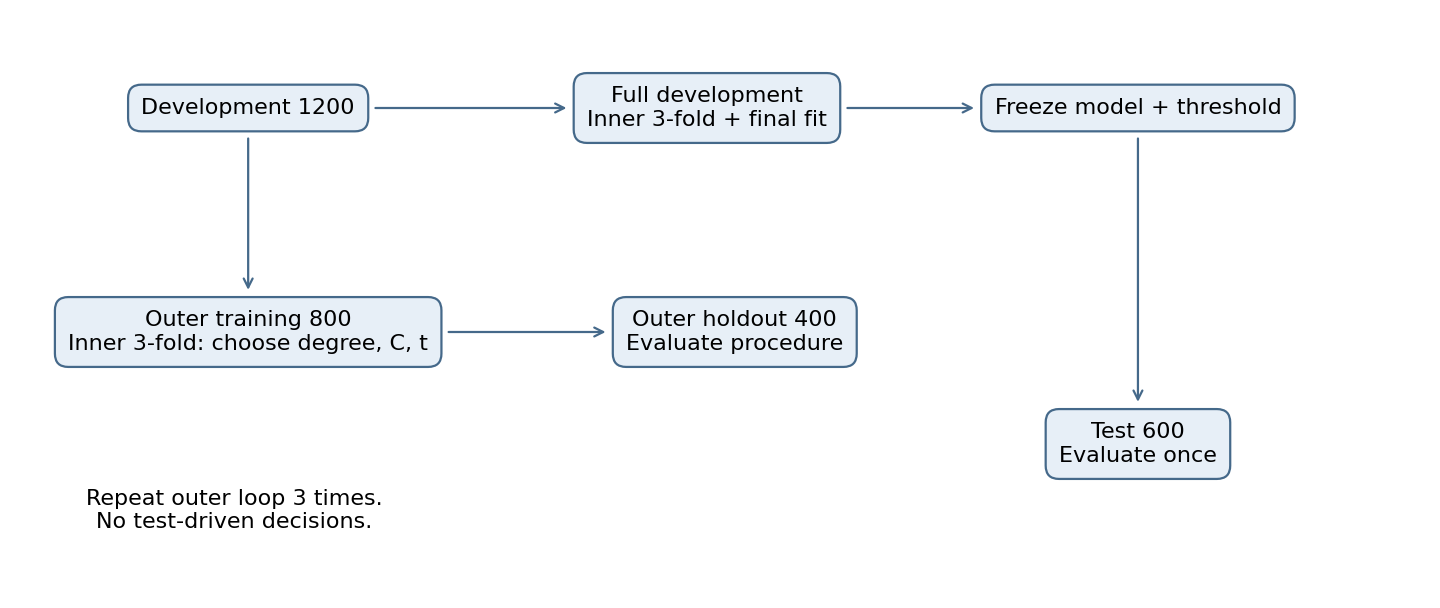

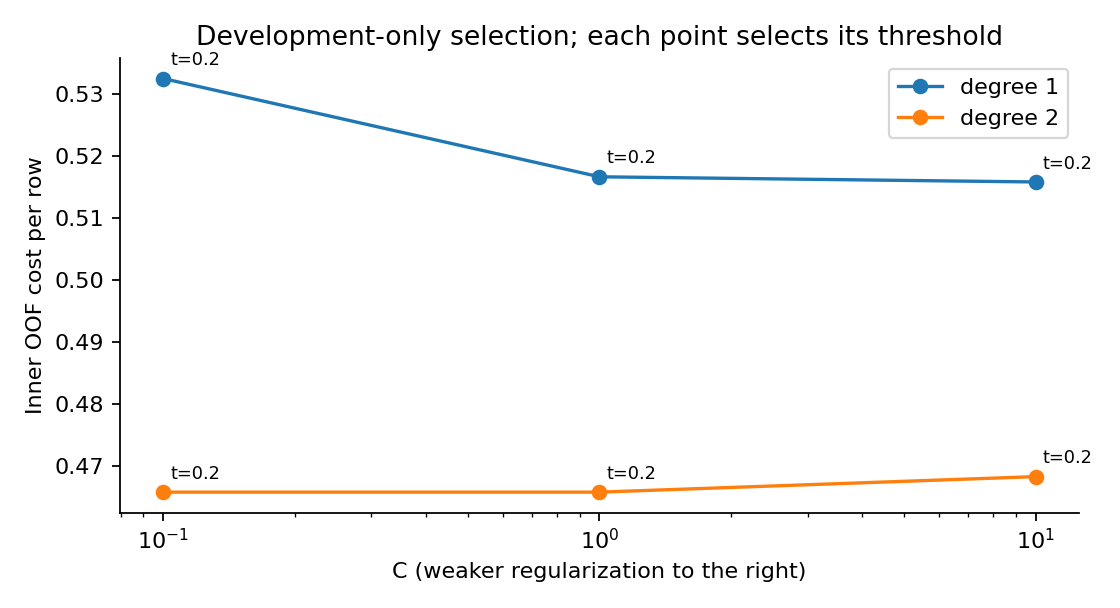

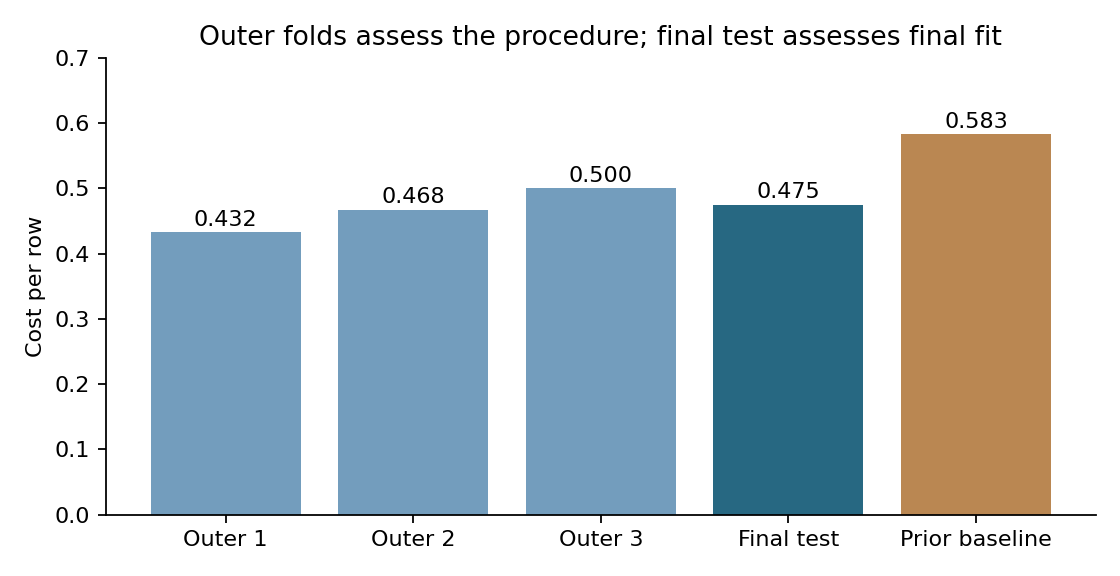

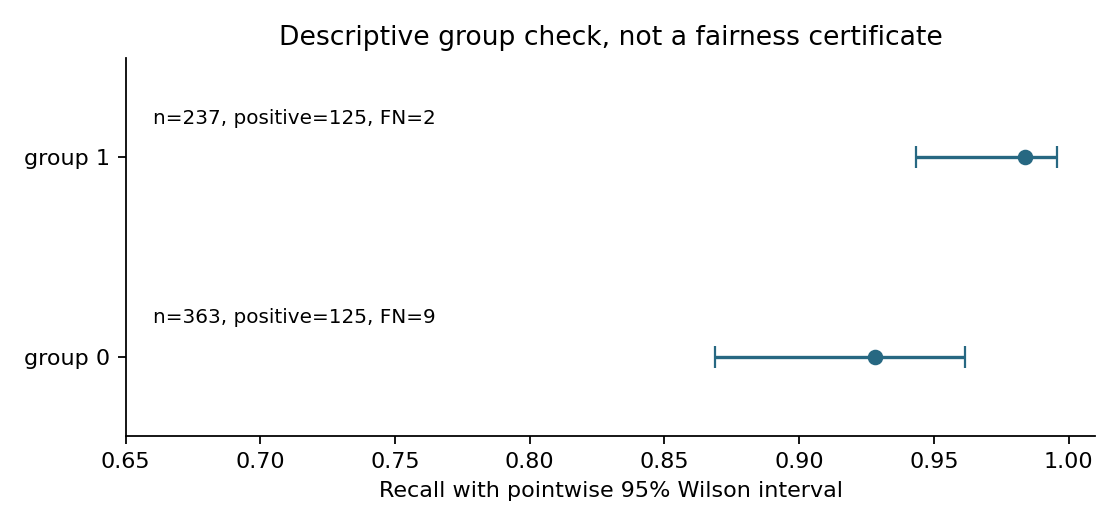

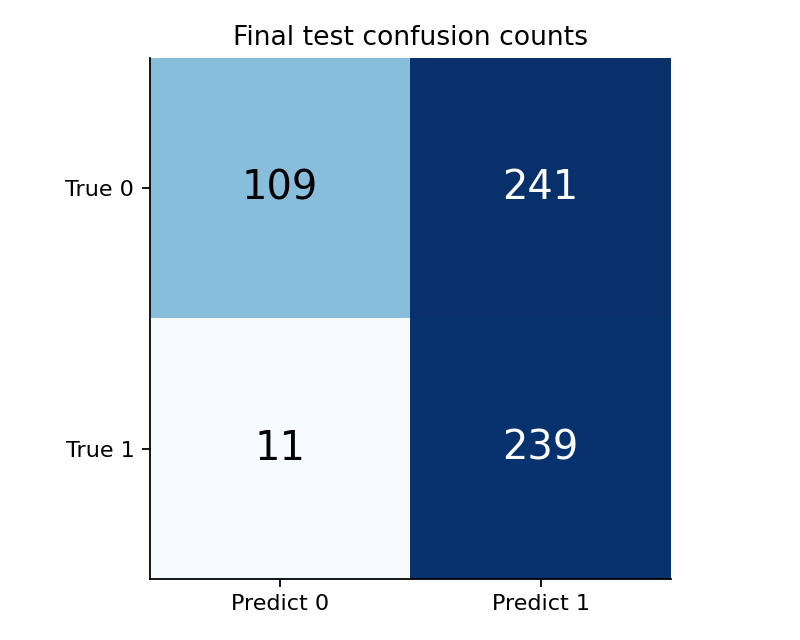

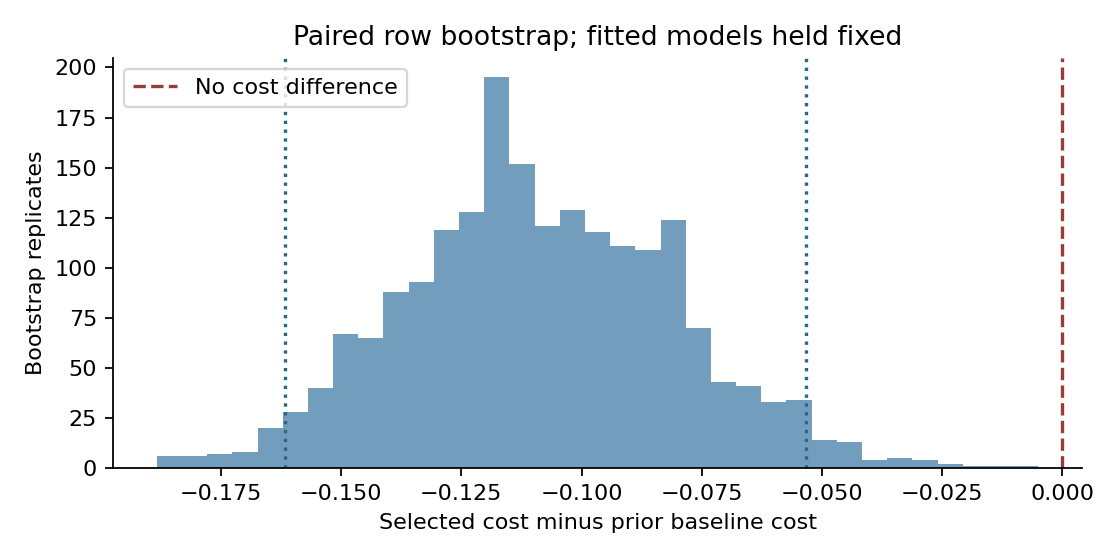

In [7]:
paths = make_figures(result, ROOT / "outputs/notebook-figures")
for path in paths:
    display(Image(filename=str(path)))

In [8]:
print("Cost difference:", result["test"]["paired_difference"])
print("Paired percentile interval:", result["test"]["paired_bootstrap_95"])
display(pd.DataFrame(result["test"]["groups"]).T[["n", "tp", "fn", "fp", "tn", "cost", "recall", "recall_wilson"]])

Cost difference: -0.10833333333333334
Paired percentile interval: [-0.16166666666666665, -0.05333333333333334]


,n,tp,fn,fp,tn,cost,recall,recall_wilson
0,363,116,9,153,85,0.520661,0.928,"[0.8688171613175633, 0.9616608616681095]"
1,237,123,2,88,24,0.405063,0.984,"[0.9435374990695339, 0.9956011998208062]"


## 留下能被反驳的结论
最终成本改进必须和241次误报一起报告。这里没有证明现实适用性或公平性。请完成lab.md的A至G和读图题，再与answers.md比较；探索修改放新输出目录，不覆盖交付数据。